In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Check uploaded files
os.listdir("/content")

['.config',
 'circuits.csv',
 'results.csv',
 'driver_standings.csv',
 'sprint_results.csv',
 'status.csv',
 'lap_times.csv',
 'constructor_standings.csv',
 'constructors.csv',
 'constructor_results.csv',
 'seasons.csv',
 'qualifying.csv',
 'races.csv',
 'drivers.csv',
 'pit_stops.csv',
 'sample_data']

In [2]:
races = pd.read_csv("/content/races.csv")
drivers = pd.read_csv("/content/drivers.csv")
constructors = pd.read_csv("/content/constructors.csv")
results = pd.read_csv("/content/results.csv")
lap_times = pd.read_csv("/content/lap_times.csv")
pit_stops = pd.read_csv("/content/pit_stops.csv")
qualifying = pd.read_csv("/content/qualifying.csv")

print("Races:", races.shape)
print("Drivers:", drivers.shape)
print("Constructors:", constructors.shape)
print("Results:", results.shape)
print("Lap Times:", lap_times.shape)
print("Pit Stops:", pit_stops.shape)
print("Qualifying:", qualifying.shape)

Races: (1125, 18)
Drivers: (861, 9)
Constructors: (212, 5)
Results: (26759, 18)
Lap Times: (589081, 6)
Pit Stops: (11371, 7)
Qualifying: (10494, 9)


#### Filter last 5 years


In [5]:
# Filter last 5 seasons: 2020 to 2024
races_5yr = races[(races["year"] >= 2020) & (races["year"] <= 2024)]

races_5yr[["raceId", "year", "round", "name", "date"]].head()

,raceId,year,round,name,date
1018,1031,2020,1,Austrian Grand Prix,2020-07-05
1019,1032,2020,2,Styrian Grand Prix,2020-07-12
1020,1033,2020,3,Hungarian Grand Prix,2020-07-19
1021,1034,2020,4,British Grand Prix,2020-08-02
1022,1035,2020,5,70th Anniversary Grand Prix,2020-08-09


###  Cheking how mant races for last 5 years


In [6]:
races_5yr["year"].value_counts().sort_index()

,count
year,
2020,17
2021,22
2022,22
2023,22
2024,24


### Merge results with drivers and constructors

In [7]:
# Prepare constructor names
constructors_small = constructors[["constructorId", "name"]].rename(
    columns={"name": "constructor_name"}
)

# Merge results with races
results_5yr = results.merge(
    races_5yr[["raceId", "year", "round", "name", "date"]],
    on="raceId",
    how="inner"
)

results_5yr = results_5yr.rename(columns={"name": "race_name"})

# Merge drivers
results_5yr = results_5yr.merge(
    drivers[["driverId", "code", "forename", "surname", "nationality"]],
    on="driverId",
    how="left"
)

# Merge constructors
results_5yr = results_5yr.merge(
    constructors_small,
    on="constructorId",
    how="left"
)

# Create full driver name
results_5yr["driver_name"] = results_5yr["forename"] + " " + results_5yr["surname"]

results_5yr.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,year,round,race_name,date,code,forename,surname,nationality,constructor_name,driver_name
0,24626,1031,822,131,77,1,1,1,1,25.0,...,2020,1,Austrian Grand Prix,2020-07-05,BOT,Valtteri,Bottas,Finnish,Mercedes,Valtteri Bottas
1,24627,1031,844,6,16,7,2,2,2,18.0,...,2020,1,Austrian Grand Prix,2020-07-05,LEC,Charles,Leclerc,Monegasque,Ferrari,Charles Leclerc
2,24628,1031,846,1,4,3,3,3,3,16.0,...,2020,1,Austrian Grand Prix,2020-07-05,NOR,Lando,Norris,British,McLaren,Lando Norris
3,24629,1031,1,131,44,5,4,4,4,12.0,...,2020,1,Austrian Grand Prix,2020-07-05,HAM,Lewis,Hamilton,British,Mercedes,Lewis Hamilton
4,24630,1031,832,1,55,8,5,5,5,10.0,...,2020,1,Austrian Grand Prix,2020-07-05,SAI,Carlos,Sainz,Spanish,McLaren,Carlos Sainz


### Top drivers by total points from 2020–2024

In [8]:
driver_points_5yr = (
    results_5yr
    .groupby("driver_name")["points"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

driver_points_5yr.head(10)

,driver_name,points
0,Max Verstappen,1964.5
1,Lewis Hamilton,1389.5
2,Charles Leclerc,1060.0
3,Sergio Pérez,1004.0
4,Carlos Sainz,936.5
5,Lando Norris,901.0
6,George Russell,664.0
7,Valtteri Bottas,499.0
8,Fernando Alonso,430.0
9,Oscar Piastri,347.0


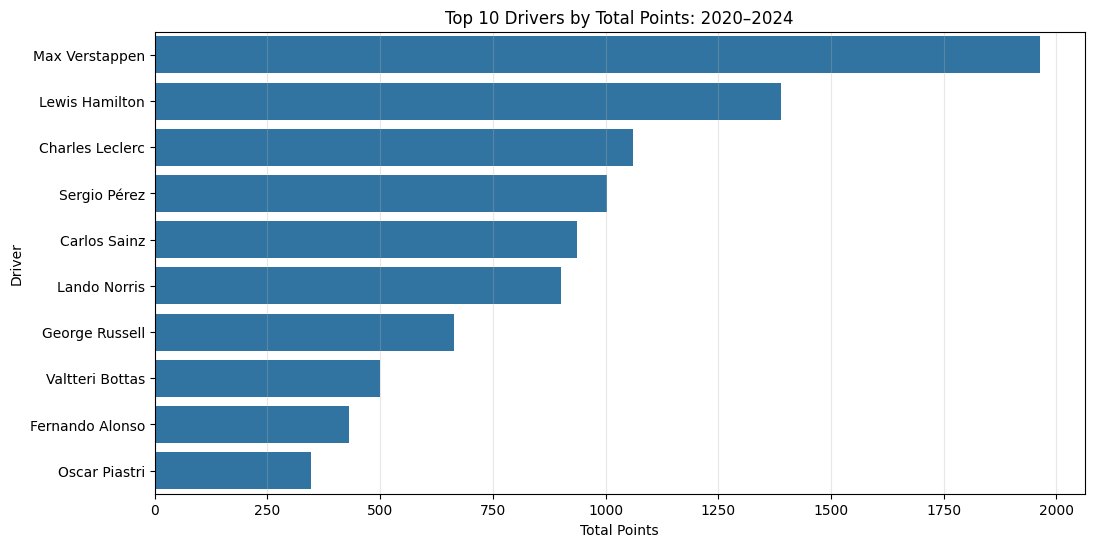

In [9]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=driver_points_5yr.head(10),
    x="points",
    y="driver_name"
)

plt.title("Top 10 Drivers by Total Points: 2020–2024")
plt.xlabel("Total Points")
plt.ylabel("Driver")
plt.grid(axis="x", alpha=0.3)
plt.show()

### Driver points trend by year

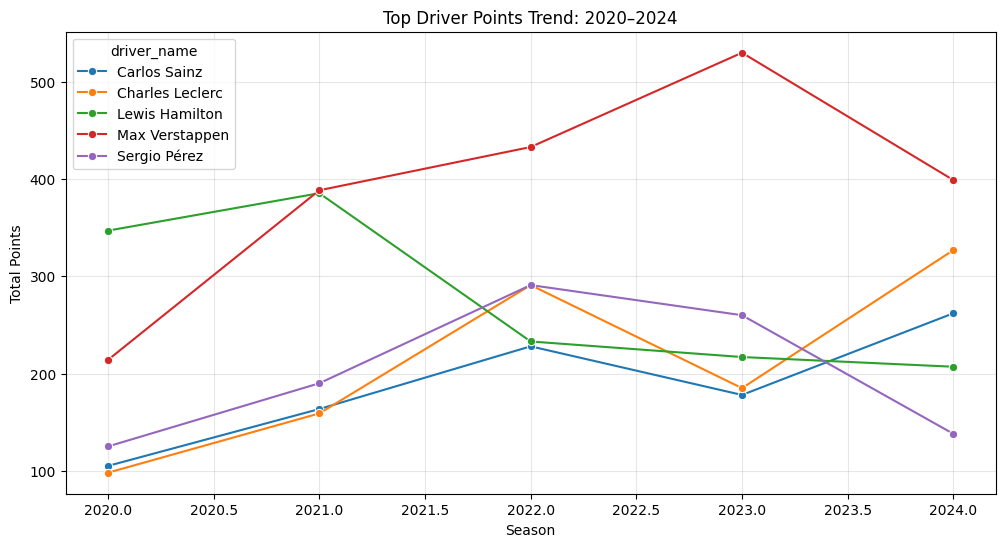

In [10]:
driver_points_year = (
    results_5yr
    .groupby(["year", "driver_name"])["points"]
    .sum()
    .reset_index()
)

top_5_drivers = driver_points_5yr.head(5)["driver_name"].tolist()

top_driver_trend = driver_points_year[
    driver_points_year["driver_name"].isin(top_5_drivers)
]

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=top_driver_trend,
    x="year",
    y="points",
    hue="driver_name",
    marker="o"
)

plt.title("Top Driver Points Trend: 2020–2024")
plt.xlabel("Season")
plt.ylabel("Total Points")
plt.grid(True, alpha=0.3)
plt.show()

### Constructor/team points from 2020–2024

In [11]:
constructor_points_5yr = (
    results_5yr
    .groupby("constructor_name")["points"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

constructor_points_5yr

,constructor_name,points
0,Red Bull,2948.5
1,Mercedes,2479.5
2,Ferrari,1930.5
3,McLaren,1501.0
4,Alpine F1 Team,498.0
5,Aston Martin,492.0
6,AlphaTauri,306.0
7,Racing Point,210.0
8,Renault,181.0
9,Haas F1 Team,96.0


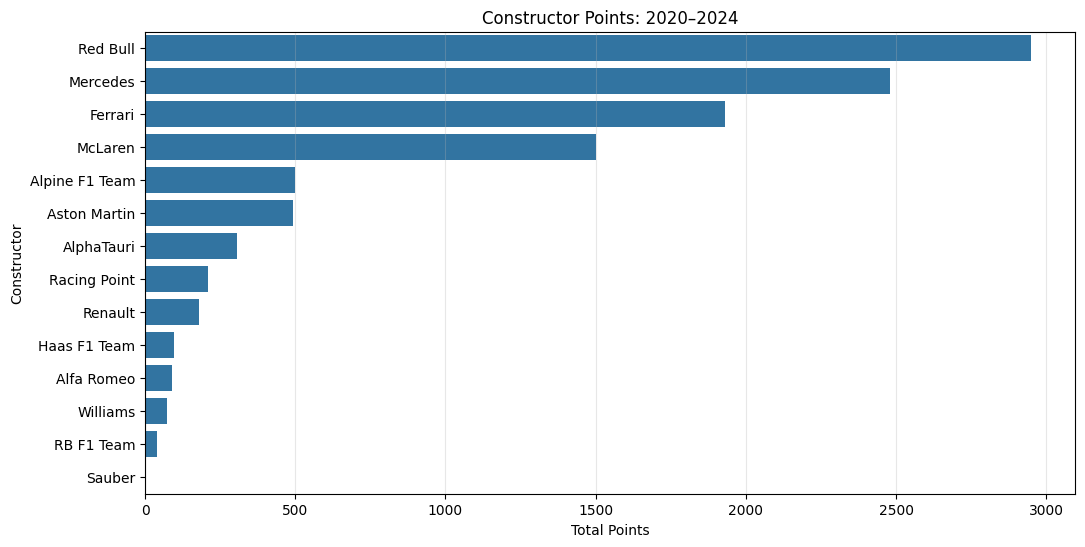

In [12]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=constructor_points_5yr,
    x="points",
    y="constructor_name"
)

plt.title("Constructor Points: 2020–2024")
plt.xlabel("Total Points")
plt.ylabel("Constructor")
plt.grid(axis="x", alpha=0.3)
plt.show()

### Constructor performance trend by year

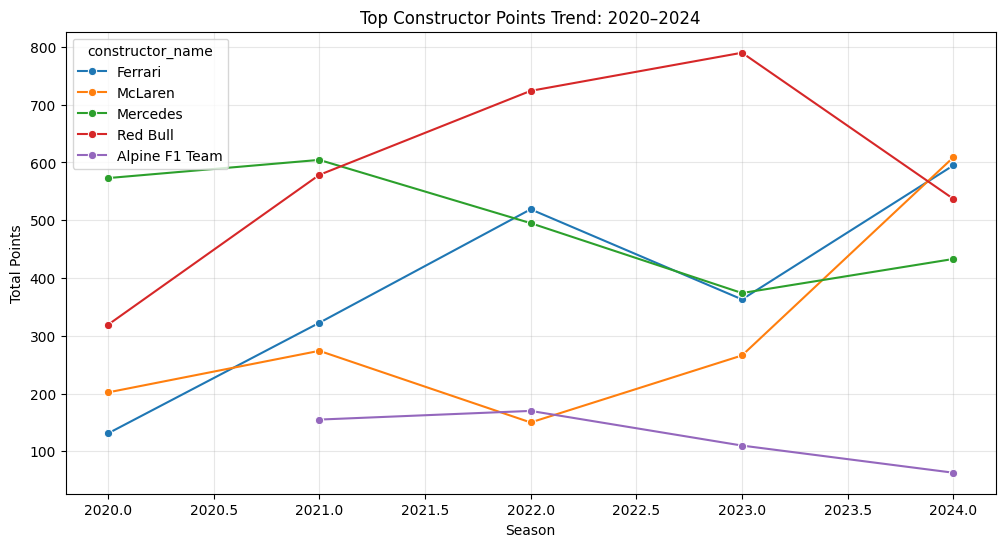

In [13]:
constructor_points_year = (
    results_5yr
    .groupby(["year", "constructor_name"])["points"]
    .sum()
    .reset_index()
)

top_5_teams = constructor_points_5yr.head(5)["constructor_name"].tolist()

top_team_trend = constructor_points_year[
    constructor_points_year["constructor_name"].isin(top_5_teams)
]

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=top_team_trend,
    x="year",
    y="points",
    hue="constructor_name",
    marker="o"
)

plt.title("Top Constructor Points Trend: 2020–2024")
plt.xlabel("Season")
plt.ylabel("Total Points")
plt.grid(True, alpha=0.3)
plt.show()

### Grid position vs final position for last 5 years

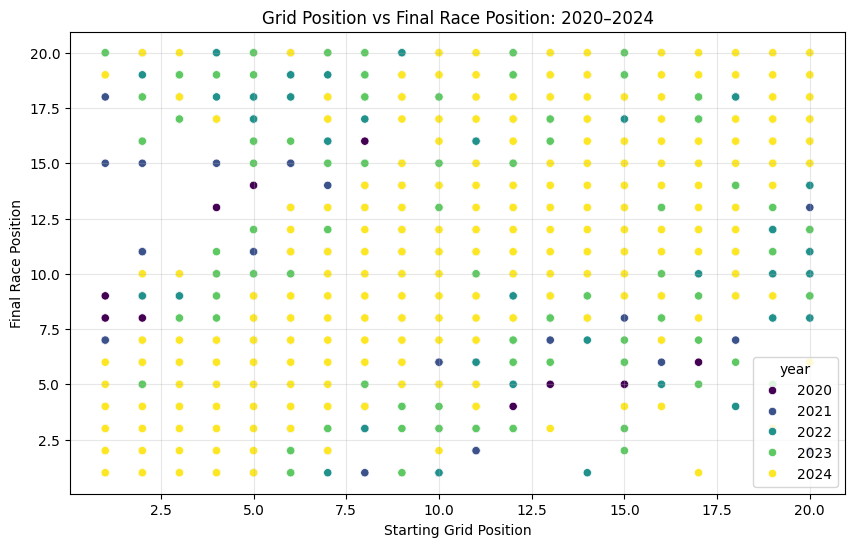

In [14]:
grid_vs_finish_5yr = results_5yr[results_5yr["grid"] > 0].copy()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=grid_vs_finish_5yr,
    x="grid",
    y="positionOrder",
    hue="year",
    palette="viridis"
)

plt.title("Grid Position vs Final Race Position: 2020–2024")
plt.xlabel("Starting Grid Position")
plt.ylabel("Final Race Position")
plt.grid(True, alpha=0.3)
plt.show()

### Race wins by driver from 2020–2024

In [15]:
wins_5yr = results_5yr[results_5yr["positionOrder"] == 1]

driver_wins = (
    wins_5yr
    .groupby("driver_name")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="wins")
)

driver_wins.head(10)

,driver_name,wins
0,Max Verstappen,55
1,Lewis Hamilton,21
2,Charles Leclerc,6
3,Sergio Pérez,6
4,Carlos Sainz,4
5,Lando Norris,4
6,George Russell,3
7,Valtteri Bottas,3
8,Oscar Piastri,2
9,Daniel Ricciardo,1


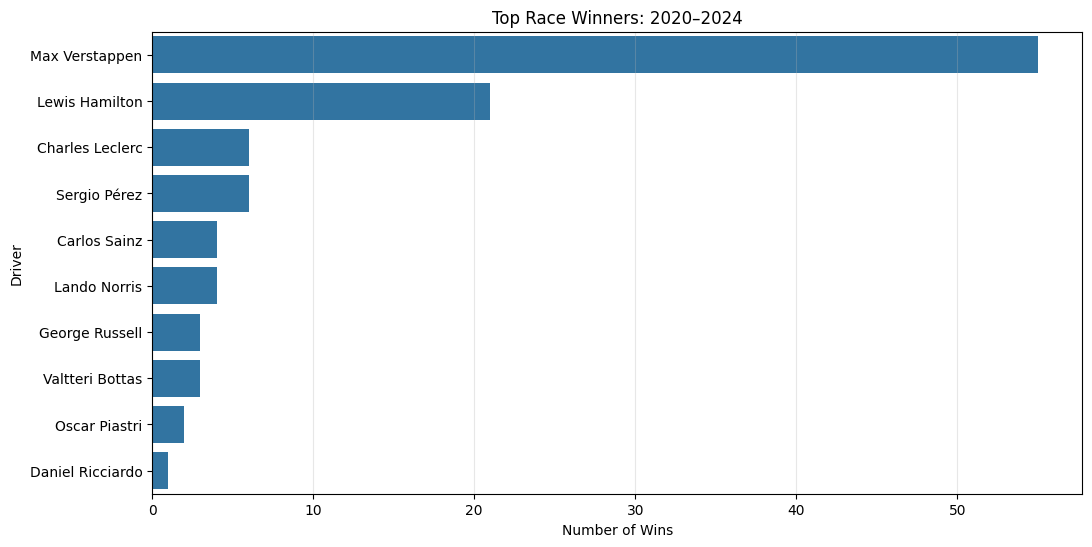

In [16]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=driver_wins.head(10),
    x="wins",
    y="driver_name"
)

plt.title("Top Race Winners: 2020–2024")
plt.xlabel("Number of Wins")
plt.ylabel("Driver")
plt.grid(axis="x", alpha=0.3)
plt.show()

### Pit stop analysis for last 5 years

In [17]:
pit_5yr = pit_stops.merge(
    races_5yr[["raceId", "year", "name"]],
    on="raceId",
    how="inner"
)

pit_5yr = pit_5yr.rename(columns={"name": "race_name"})

pit_5yr = pit_5yr.merge(
    drivers[["driverId", "forename", "surname"]],
    on="driverId",
    how="left"
)

pit_5yr["driver_name"] = pit_5yr["forename"] + " " + pit_5yr["surname"]
pit_5yr["milliseconds"] = pd.to_numeric(pit_5yr["milliseconds"], errors="coerce")
pit_5yr["pit_seconds"] = pit_5yr["milliseconds"] / 1000

avg_pit_5yr = (
    pit_5yr
    .groupby("driver_name")["pit_seconds"]
    .mean()
    .sort_values()
    .reset_index()
)

avg_pit_5yr.head(10)

,driver_name,pit_seconds
0,Jack Doohan,22.080000
1,Robert Kubica,22.104500
2,Franco Colapinto,24.123900
3,Pietro Fittipaldi,26.316833
4,Jack Aitken,30.193000
5,Kevin Magnussen,92.343930
6,Alexander Albon,107.626993
7,Nyck de Vries,111.017474
8,Guanyu Zhou,121.417674
9,Nico Hülkenberg,123.464269


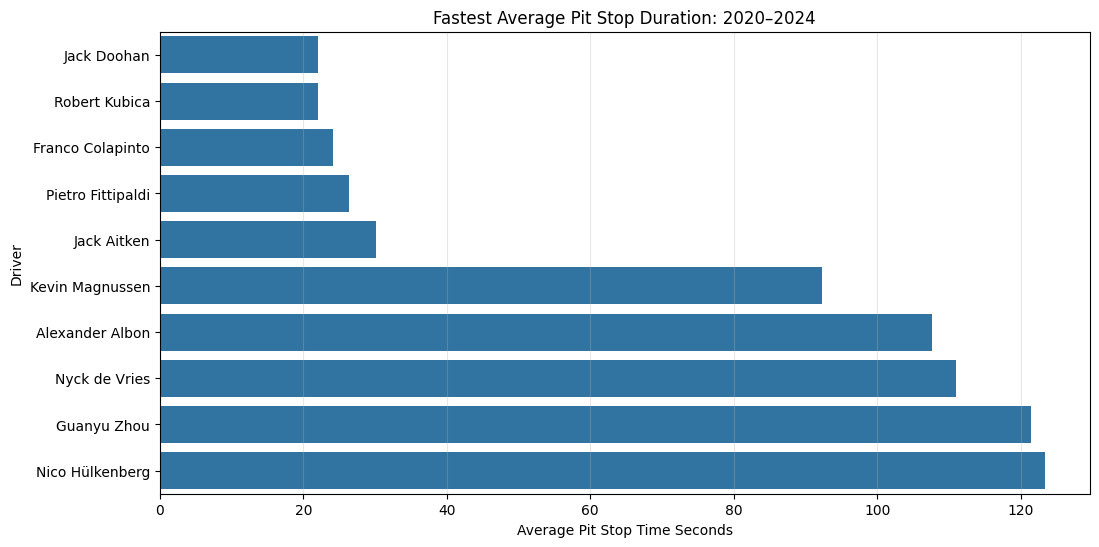

In [18]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=avg_pit_5yr.head(10),
    x="pit_seconds",
    y="driver_name"
)

plt.title("Fastest Average Pit Stop Duration: 2020–2024")
plt.xlabel("Average Pit Stop Time Seconds")
plt.ylabel("Driver")
plt.grid(axis="x", alpha=0.3)
plt.show()

### Lap time analysis for one selected race

In [20]:
laps_5yr = lap_times.merge(
    races_5yr[["raceId", "year", "name"]],
    on="raceId",
    how="inner"
)

laps_5yr = laps_5yr.rename(columns={"name": "race_name"})

laps_5yr = laps_5yr.merge(
    drivers[["driverId", "forename", "surname"]],
    on="driverId",
    how="left"
)

laps_5yr["driver_name"] = laps_5yr["forename"] + " " + laps_5yr["surname"]
laps_5yr["lap_seconds"] = laps_5yr["milliseconds"] / 1000

british_2024_laps = laps_5yr[
    (laps_5yr["year"] == 2024) &
    (laps_5yr["race_name"] == "British Grand Prix")
]

british_2024_laps.head()

,raceId,driverId,lap,position,time,milliseconds,year,race_name,forename,surname,driver_name,lap_seconds
102525,1132,847,1,1,1:35.211,95211,2024,British Grand Prix,George,Russell,George Russell,95.211
102526,1132,847,2,1,1:31.418,91418,2024,British Grand Prix,George,Russell,George Russell,91.418
102527,1132,847,3,1,1:31.298,91298,2024,British Grand Prix,George,Russell,George Russell,91.298
102528,1132,847,4,1,1:31.799,91799,2024,British Grand Prix,George,Russell,George Russell,91.799
102529,1132,847,5,1,1:31.628,91628,2024,British Grand Prix,George,Russell,George Russell,91.628


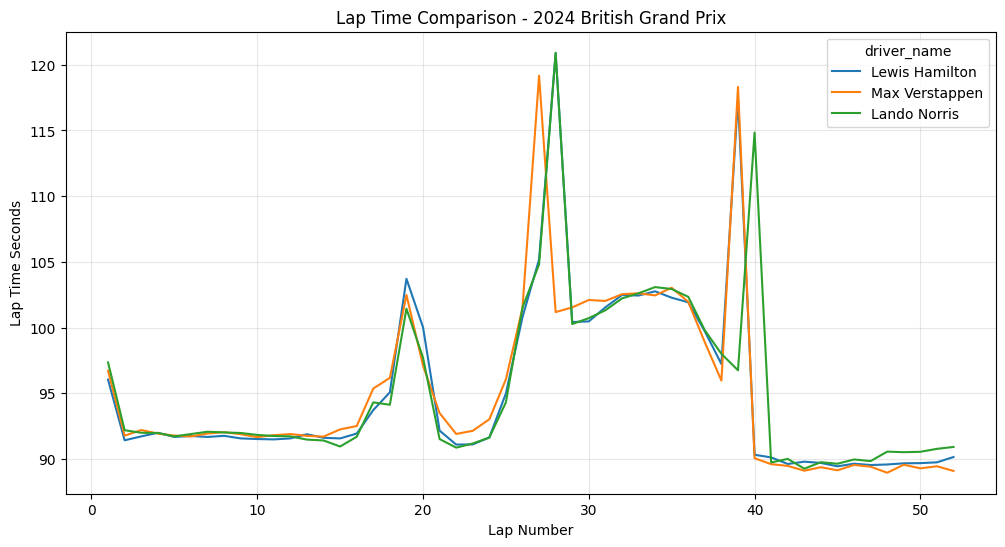

In [21]:
selected_drivers = ["Lewis Hamilton", "Max Verstappen", "Lando Norris"]

selected_laps = british_2024_laps[
    british_2024_laps["driver_name"].isin(selected_drivers)
]

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=selected_laps,
    x="lap",
    y="lap_seconds",
    hue="driver_name"
)

plt.title("Lap Time Comparison - 2024 British Grand Prix")
plt.xlabel("Lap Number")
plt.ylabel("Lap Time Seconds")
plt.grid(True, alpha=0.3)
plt.show()